#**Netflix Movie Recommendation Engine**

Phase-1: Environment setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import concurrent.futures
import re
import time
import os
import gc
import pickle
import implicit
import pyarrow.parquet as pq
import pyarrow as pa

from pathlib import Path
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm
from dotenv import load_dotenv


from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split, GridSearchCV
from surprise.accuracy import rmse as s_rmse, mae as s_mae


/workspaces/Netflix-movie-recommendation-engine/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()
TMDB_API_KEY = os.getenv("TMDB_API_KEY")

cwd = Path.cwd()
if cwd.name == "notebooks":
    root_dir = cwd.parent
else:
    root_dir = cwd

PROJECT_PATH = root_dir / "data"
print(f"Data path resolving to: {PROJECT_PATH}")

Data path resolving to: /workspaces/Netflix-movie-recommendation-engine/data


**Phase-2: Data Ingestion and parsing**

In [3]:
def parse_netflix_ratings_to_parquet(file_path, out_parquet, chunk_size=200_000):
    """Parse Netflix combined_data file and write it to Parquet in chunks."""
    
    cols = ["MovieID", "CustomerID", "Rating", "Date"]
    buffer = []
    writer = None

    def flush_buffer():
        nonlocal writer
        if not buffer:
            return

        df_chunk = pd.DataFrame(buffer, columns=cols)
        df_chunk["MovieID"] = df_chunk["MovieID"].astype("int32")
        df_chunk["CustomerID"] = df_chunk["CustomerID"].astype("int32")
        df_chunk["Rating"] = df_chunk["Rating"].astype("int8")
        df_chunk["Date"] = pd.to_datetime(df_chunk["Date"], errors="coerce")

        table = pa.Table.from_pandas(df_chunk, preserve_index=False)
        if writer is None:
            # Cast out_parquet to string for safe pyarrow execution
            writer = pq.ParquetWriter(str(out_parquet), table.schema)
        writer.write_table(table)
        buffer.clear()

    current_movie_id = None
    
    with open(str(file_path), 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc="Parsing Netflix ratings", unit="lines"):
            line = line.strip()
            if not line:
                continue
            if line.endswith(":"):
                current_movie_id = int(line[:-1])
                continue

            customer_id, rating, date = line.split(",")
            buffer.append([
                current_movie_id,
                int(customer_id),
                int(rating),
                date
            ])

            if len(buffer) >= chunk_size:
                flush_buffer()

    flush_buffer()
    if writer is not None:
        writer.close()

    return out_parquet


def read_parquet_head(file_path, n=5):
    """Reads first few rows of a Parquet file for previewing."""
    parquet_file = pq.ParquetFile(str(file_path))
    table = parquet_file.read_row_group(0)
    return table.slice(0, n).to_pandas()

In [4]:
ratings = pd.read_parquet(
    os.path.join(PROJECT_PATH, 'ratings.parquet')
)

ratings.head()

,MovieID,CustomerID,Rating,Date
0,1,1488844,3,2005-09-06
1,1,822109,5,2005-05-13
2,1,885013,4,2005-10-19
3,1,30878,4,2005-12-26
4,1,823519,3,2004-05-03


In [5]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 24053764 entries, 0 to 24053763
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   MovieID     int32         
 1   CustomerID  int32         
 2   Rating      int8          
 3   Date        datetime64[us]
dtypes: datetime64[us](1), int32(2), int8(1)
memory usage: 390.0 MB


In [6]:
#Load Movie Metadata

movies = []

with open(os.path.join(PROJECT_PATH, 'movie_titles.csv'), encoding="latin-1") as f:
    for line in f:
        parts = line.strip().split(",", 2)

        if len(parts) == 3:
            movie_id, year, title = parts
        elif len(parts) == 2:
            movie_id, title = parts
            year = None
        else:
            continue

        movies.append([movie_id, year, title])

movies = pd.DataFrame(
    movies,
    columns=["Movie_ID", "Year", "Title"]
)

movies["Movie_ID"] = movies["Movie_ID"].astype("int32")
movies["Year"] = pd.to_numeric(movies["Year"], errors="coerce")

In [7]:
print("Shape:", movies.shape)

print("\nColumns:")
print(movies.columns)

print("\nInfo:")
print(movies.info())

print("\nMissing Values:")
print(movies.isnull().sum())

print("\nDuplicates:")
print(movies.duplicated().sum())

Shape: (17770, 3)

Columns:
Index(['Movie_ID', 'Year', 'Title'], dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 17770 entries, 0 to 17769
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Movie_ID  17770 non-null  int32  
 1   Year      17763 non-null  float64
 2   Title     17770 non-null  str    
dtypes: float64(1), int32(1), str(1)
memory usage: 713.8 KB
None

Missing Values:
Movie_ID    0
Year        7
Title       0
dtype: int64

Duplicates:
0


**Phase 3 — Genre Enrichment**

In [8]:
#Genre ID mapping

genre_map = {
    28:"Action",
    12:"Adventure",
    16:"Animation",
    35:"Comedy",
    80:"Crime",
    99:"Documentary",
    18:"Drama",
    10751:"Family",
    14:"Fantasy",
    36:"History",
    27:"Horror",
    10402:"Music",
    9648:"Mystery",
    10749:"Romance",
    878:"Science Fiction",
    10770:"TV Movie",
    53:"Thriller",
    10752:"War",
    37:"Western",
    10759: "Action & Adventure",
    10762: "Kids",
    10763: "News",
    10764: "Reality",
    10765: "Sci-Fi & Fantasy",
    10766: "Soap",
    10767: "Talk",
    10768: "War & Politics"
}

In [9]:
def clean_title(title):
    """Cleans movie titles for better TMDb API matching."""
    title = re.sub(r":\s*Bonus Material.*", "", title, flags=re.IGNORECASE)
    title = re.sub(r":\s*Special Edition.*", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\(Widescreen\)", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\bSeason\s+\d+\b", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\bVol\.?\s*\d+\b", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\bVolume\s+\d+\b", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\bPart\s+\d+\b", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\bSet\s+\d+\b", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\bDisc\s+\d+\b", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\bDouble Feature\b", "", title, flags=re.IGNORECASE)
    title = re.sub(r"\s+", " ", title).strip(" :-")
    return title

In [10]:
def get_movie_genres(title, year, token, max_retries=3):
    """Fetches genres from TMDb API for a given title and year, with rate limit retries."""
    headers = {
        "accept": "application/json",
        "Authorization": f"Bearer {token}"
    }

    cleaned_title = clean_title(title)

    def search(endpoint, year_filter=None):
        params = {"query": cleaned_title}
        if pd.notna(year_filter):
            params["year" if endpoint == "movie" else "first_air_date_year"] = int(year_filter)

        for attempt in range(max_retries):
            try:
                response = requests.get(f"https://api.themoviedb.org/3/search/{endpoint}", headers=headers, params=params, timeout=10)
                
                if response.status_code == 200:
                    return response.json().get("results", [])
                elif response.status_code == 429:  # Rate Limit Hit
                    time.sleep(1.5)  # Pause to let the API cool down
                    continue
                else:
                    return []
            except Exception: # Catch timeouts or connection errors
                if attempt == max_retries - 1:
                    return []
                time.sleep(1)
                
        return []

    results = search("movie", year) or search("movie") or search("tv", year) or search("tv")
    if not results: return "Unknown"

    selected = None
    if pd.notna(year):
        target_year = str(int(year))
        for item in results:
            release = item.get("release_date") or item.get("first_air_date") or ""
            if release.startswith(target_year):
                selected = item
                break

    if selected is None:
        selected = max(results, key=lambda x: x.get("popularity", 0))

    genres = [genre_map.get(gid, str(gid)) for gid in selected.get("genre_ids", [])]
    return ", ".join(genres) if genres else "Unknown"

In [11]:
def enrich_movie_genres(movies_df, token, batch_size=500, save_path=None):
    if "Genre" not in movies_df.columns:
        movies_df["Genre"] = None

    missing_idx = movies_df[movies_df["Genre"].isna()].index.tolist()
    total_missing = len(missing_idx)

    if total_missing == 0:
        print("No missing genres to enrich!")
        return movies_df

    print(f"Total missing movies to enrich: {total_missing}")

    def fetch_worker(idx):
        title = movies_df.at[idx, "Title"]
        year = movies_df.at[idx, "Year"]
        genre_result = get_movie_genres(title, year, token)
        return idx, genre_result

    for start in range(0, total_missing, batch_size):
        batch_indices = missing_idx[start : start + batch_size]
        print(f"\nProcessing batch {start} to {start + len(batch_indices)}...")

        # REDUCED WORKERS: Dropped from 20 to 5 to prevent API Rate Limiting
        with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
            results = list(tqdm(
                executor.map(fetch_worker, batch_indices),
                total=len(batch_indices),
                desc="Fetching Parallelly"
            ))

        for idx, genre in results:
            movies_df.at[idx, "Genre"] = genre

        if save_path:
            movies_df.to_csv(save_path, index=False)

    return movies_df

In [12]:
# Initialize column if missing
if 'Genre' not in movies.columns:
    movies['Genre'] = "Unknown"

# Convert 'Unknown' back to None so the enrichment function targets them again
movies.loc[movies["Genre"] == "Unknown", "Genre"] = None

print(f"Movies ready to be re-enriched: {movies['Genre'].isna().sum()}")

Movies ready to be re-enriched: 17770


In [13]:
genres_path = os.path.join(PROJECT_PATH, 'movies_with_genres.csv')

if os.path.exists(genres_path):
    print("Saved movie genres found. Loading...Loaded")
    movies = pd.read_csv(genres_path)
else:
    movies = enrich_movie_genres(
        movies,
        TMDB_API_KEY,
        batch_size=500,
        save_path=genres_path
    )

Saved movie genres found. Loading...Loaded


In [14]:
movies["Genre"].value_counts().head(20)

Genre
Unknown                   2508
Drama                      981
Documentary                847
Comedy                     754
Drama, Romance             542
Music                      396
Comedy, Romance            357
Comedy, Drama              327
Horror                     255
Comedy, Drama, Romance     228
Documentary, Music         169
Music, Documentary         169
Drama, Comedy              145
Crime, Drama               134
Action, Thriller           130
Drama, Thriller            124
Drama, TV Movie            120
Horror, Thriller           119
Animation                  100
Comedy, Crime               99
Name: count, dtype: int64

In [15]:
unknown_movies = movies[movies["Genre"] == "Unknown"]

unknown_movies[["Title", "Year"]].head(50)

,Title,Year
1,Isle of Man TT 2004 Review,2004.0
3,Paula Abdul's Get Up & Dance,1994.0
10,Full Frame: Documentary Shorts,1999.0
22,Clifford: Clifford Saves the Day! / Clifford's...,2001.0
24,Inspector Morse 31: Death Is Now My Neighbour,1997.0
31,ABC Primetime: Mel Gibson's The Passion of the...,2004.0
33,Ashtanga Yoga: Beginner's Practice with Nicki ...,2003.0
61,Ken Burns' America: Empire of the Air,1991.0
69,Tai Chi: The 24 Forms,1999.0
72,Davy Crockett: 50th Anniversary Double Feature,1954.0


In [16]:
movies["Genre"].isna().sum()

np.int64(0)

In [17]:
unknown = (movies["Genre"] == "Unknown").sum()

print(f"Unknown : {unknown}")

Unknown : 2508


In [18]:
movies[movies["Genre"] == "Unknown"][["Title", "Year"]].sample(20, random_state=42)

,Title,Year
14979,Angelina Ballerina: The Lucky Penny,2002.0
460,Nightwalker #1: Midnight Detective,2000.0
17598,Art: 21: Art in the 21st Century: Seasons 1 and 2,2004.0
9259,Mystery Science Theater 3000: Timechasers,1997.0
11222,Mind of a Serial Killer: Nova,1992.0
5634,The Mafia: An Expose - Gotti and a Mafia Resume,1998.0
1289,Hitler's Lost Sub: Nova,2000.0
6642,Hookers at the Point,2002.0
7015,Raging Bull: Collector's Edition: Bonus Material,1980.0
5753,The Great Aviator: Howard Hughes,2004.0


In [19]:
df = ratings.merge(
    movies,
    left_on="MovieID",
    right_on="Movie_ID",
    how="left"
)

del ratings
gc.collect()

df.drop(columns="Movie_ID", inplace=True)
df.rename(columns={"MovieID": "Movie_ID"}, inplace=True)

In [20]:
df["Title"] = df["Title"].astype("category")
df["Genre"] = df["Genre"].astype("category")

df.to_parquet(
    PROJECT_PATH / 'netflix_final_dataset.parquet',
    index=False
)

Genres are enriched using the TMDb API through automated title and year matching, with fallback searches against both movie and TV endpoints. Approximately 86% of titles are matched successfully. Unmatched titles are labeled as "Unknown" and excluded only from genre-specific analyses while remaining in the recommendation dataset

In [21]:
print(df.columns)

Index(['Movie_ID', 'CustomerID', 'Rating', 'Date', 'Year', 'Title', 'Genre'], dtype='str')


In [22]:
# Clean up local variables and trigger garbage collection
gc.collect()

0

In [23]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

Shape: (24053764, 7)

Columns:
Index(['Movie_ID', 'CustomerID', 'Rating', 'Date', 'Year', 'Title', 'Genre'], dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 24053764 entries, 0 to 24053763
Data columns (total 7 columns):
 #   Column      Dtype         
---  ------      -----         
 0   Movie_ID    int32         
 1   CustomerID  int32         
 2   Rating      int8          
 3   Date        datetime64[us]
 4   Year        float64       
 5   Title       category      
 6   Genre       category      
dtypes: category(2), datetime64[us](1), float64(1), int32(2), int8(1)
memory usage: 665.4 MB
None

Missing Values:
Movie_ID        0
CustomerID      0
Rating          0
Date            0
Year          189
Title           0
Genre           0
dtype: int64

Duplicates:


0


## Phase 4 — Exploratory Data Analysis (EDA)

In this phase, the enriched Netflix dataset is analyzed to understand user rating behavior, movie popularity, genre distribution, and other insights before building recommendation models.

In [24]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (24053764, 7)

Columns:
['Movie_ID', 'CustomerID', 'Rating', 'Date', 'Year', 'Title', 'Genre']

Data Types:
Movie_ID               int32
CustomerID             int32
Rating                  int8
Date          datetime64[us]
Year                 float64
Title               category
Genre               category
dtype: object

Missing Values:
Movie_ID        0
CustomerID      0
Rating          0
Date            0
Year          189
Title           0
Genre           0
dtype: int64


In [25]:
df.describe(include="all")

,Movie_ID,CustomerID,Rating,Date,Year,Title,Genre
count,2.405376e+07,2.405376e+07,2.405376e+07,24053764,2.405358e+07,24053764,24053764
unique,NaN,NaN,NaN,NaN,NaN,4475,1131
top,NaN,NaN,NaN,NaN,NaN,Pirates of the Caribbean: The Curse of the Bla...,Drama
freq,NaN,NaN,NaN,NaN,NaN,193941,1351188
mean,2.308324e+03,1.322285e+06,3.599634e+00,2004-10-10 15:29:13.151646,1.994406e+03,NaN,NaN
min,1.000000e+00,6.000000e+00,1.000000e+00,1999-11-11 00:00:00,1.915000e+03,NaN,NaN
25%,1.180000e+03,6.609270e+05,3.000000e+00,2004-04-30 00:00:00,1.991000e+03,NaN,NaN
50%,2.342000e+03,1.318602e+06,4.000000e+00,2005-01-19 00:00:00,1.999000e+03,NaN,NaN
75%,3.433000e+03,1.984358e+06,4.000000e+00,2005-06-30 00:00:00,2.003000e+03,NaN,NaN
max,4.499000e+03,2.649429e+06,5.000000e+00,2005-12-31 00:00:00,2.005000e+03,NaN,NaN


<Axes: xlabel='Rating', ylabel='count'>

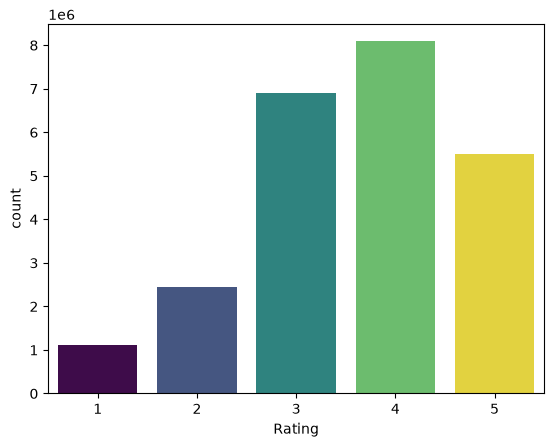

In [26]:
sns.countplot(
    x="Rating",
    data=df,
    hue="Rating",
    palette="viridis",
    legend=False
)

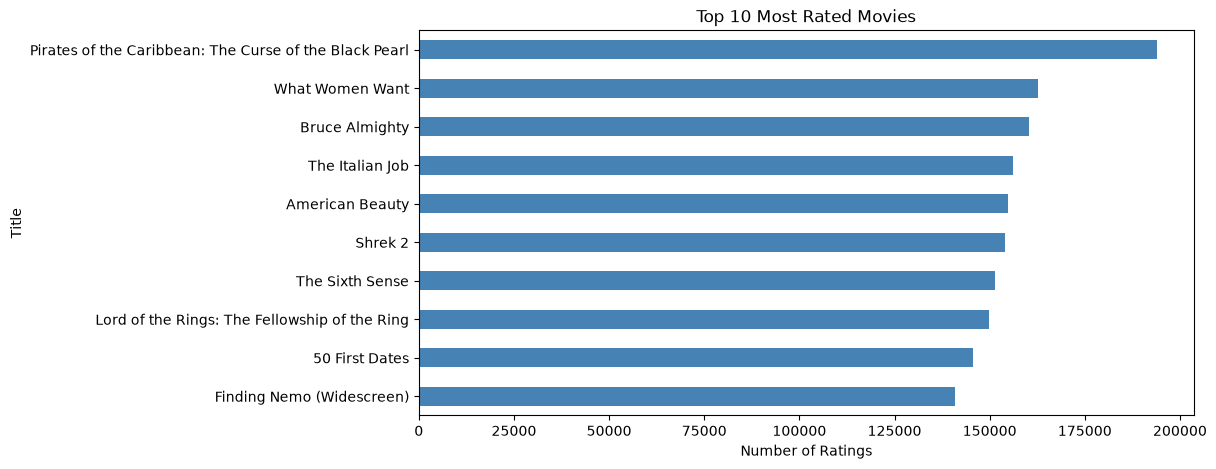

In [27]:
most_rated = (
    df.groupby("Title")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

most_rated.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")

plt.show()

In [28]:
top_rated = df.groupby("Title").agg(
    Average_Rating = ("Rating", "mean"),
    Rating_count=("Rating", "count")
    )

top_rated = top_rated[
    top_rated["Rating_count"] >= 500
]

top_rated = top_rated.sort_values(
    "Average_Rating",
    ascending=False)
top_rated.head(10)

,Average_Rating,Rating_count
Title,,
Lost: Season 1,4.670989,7249
The Simpsons: Season 6,4.581296,8426
Inu-Yasha,4.554434,1883
Family Guy: Freakin' Sweet Collection,4.516007,10027
The West Wing: Season 3,4.473692,6633
Six Feet Under: Season 4,4.469693,11829
Samurai Champloo,4.467500,2000
Inu-Yasha: The Movie 3: Swords of an Honorable Ruler,4.464824,796
Stargate SG-1: Season 8,4.461921,1812


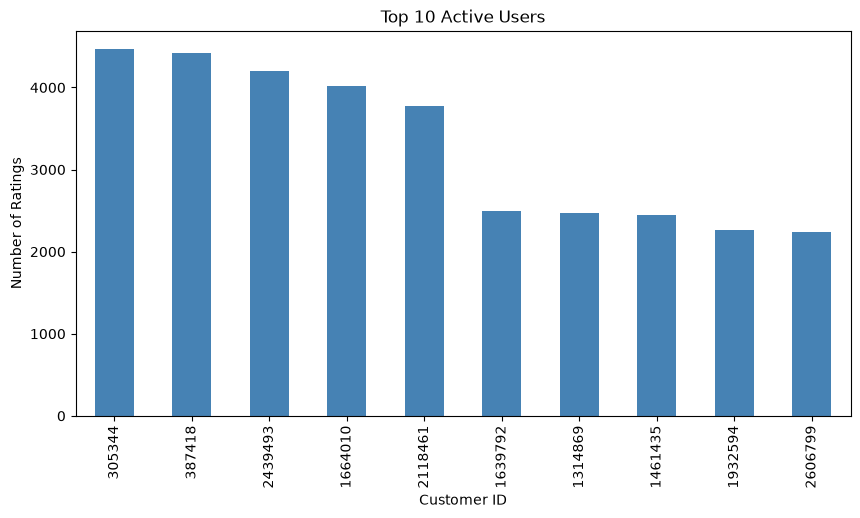

In [29]:
active_users=(
    df.groupby("CustomerID")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

active_users.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Active Users")
plt.xlabel("Customer ID")
plt.ylabel("Number of Ratings")

plt.show()

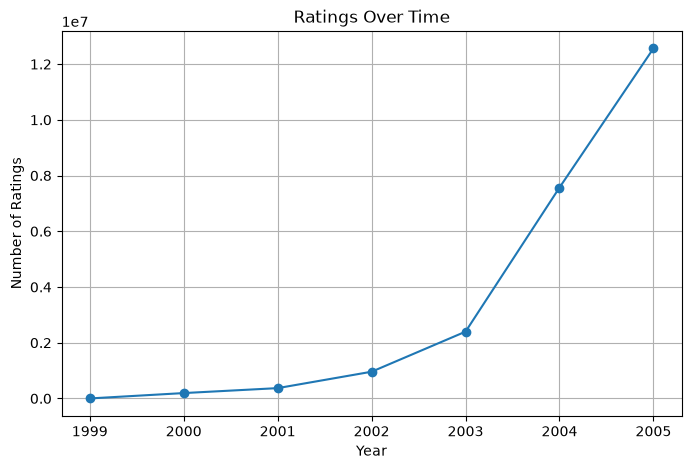

In [30]:
ratings_per_year = (
    df.groupby(df["Date"].dt.year)
      .size()
)

plt.figure(figsize=(8,5))

ratings_per_year.plot(
    marker="o"
)

plt.title("Ratings Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")

plt.grid(True)

plt.show()

In [31]:
df["Genre"] = df["Genre"].str.split(", ")

genre_counts = df[df["Genre"].notna()].explode("Genre").groupby("Genre").size()

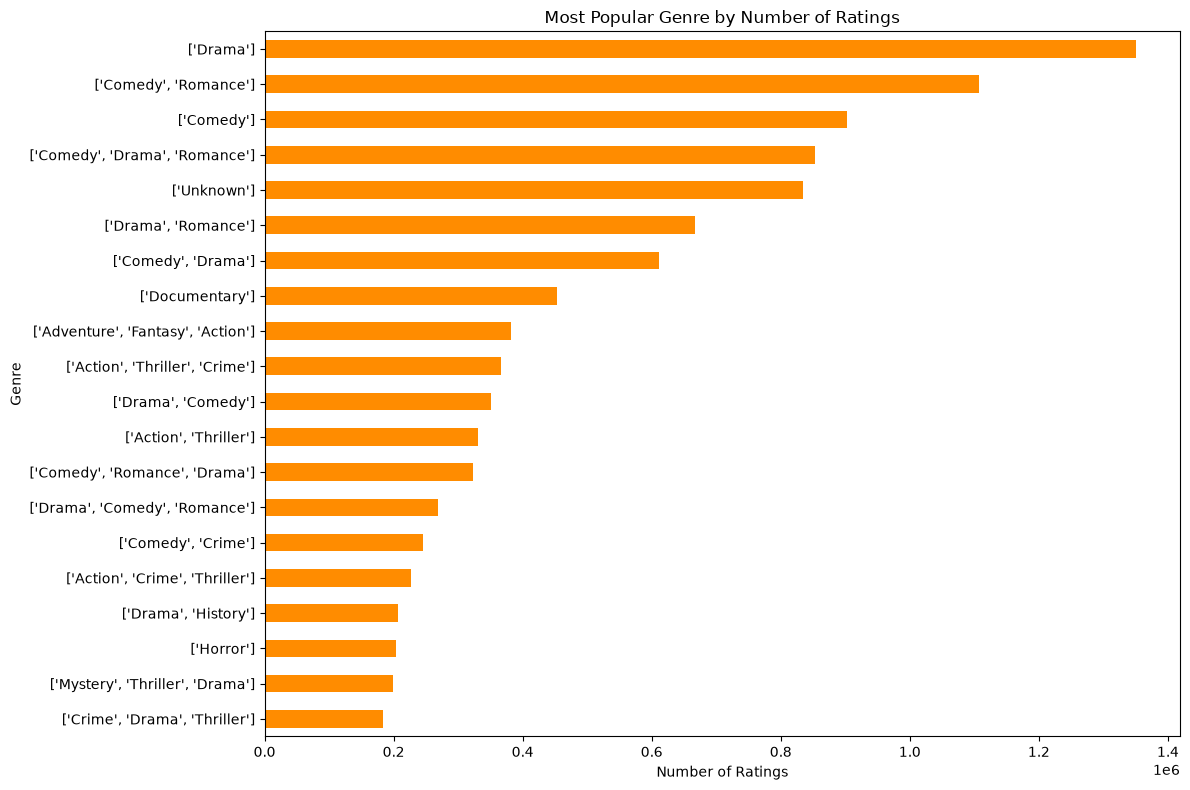

In [32]:
genre_counts = (
    df[df["Genre"].notna()]
    .explode("Genre")
)

genre_counts = (
    genre_counts[genre_counts["Genre"] != "Unknown"]
    .groupby("Genre", observed=True)
    .size()
    .sort_values(ascending=False)
)

top_genres = genre_counts.head(20)

plt.figure(figsize=(12, 8))
top_genres.sort_values().plot(
    kind="barh",
    color="darkorange"
)

plt.title("Most Popular Genre by Number of Ratings")
plt.xlabel("Number of Ratings")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

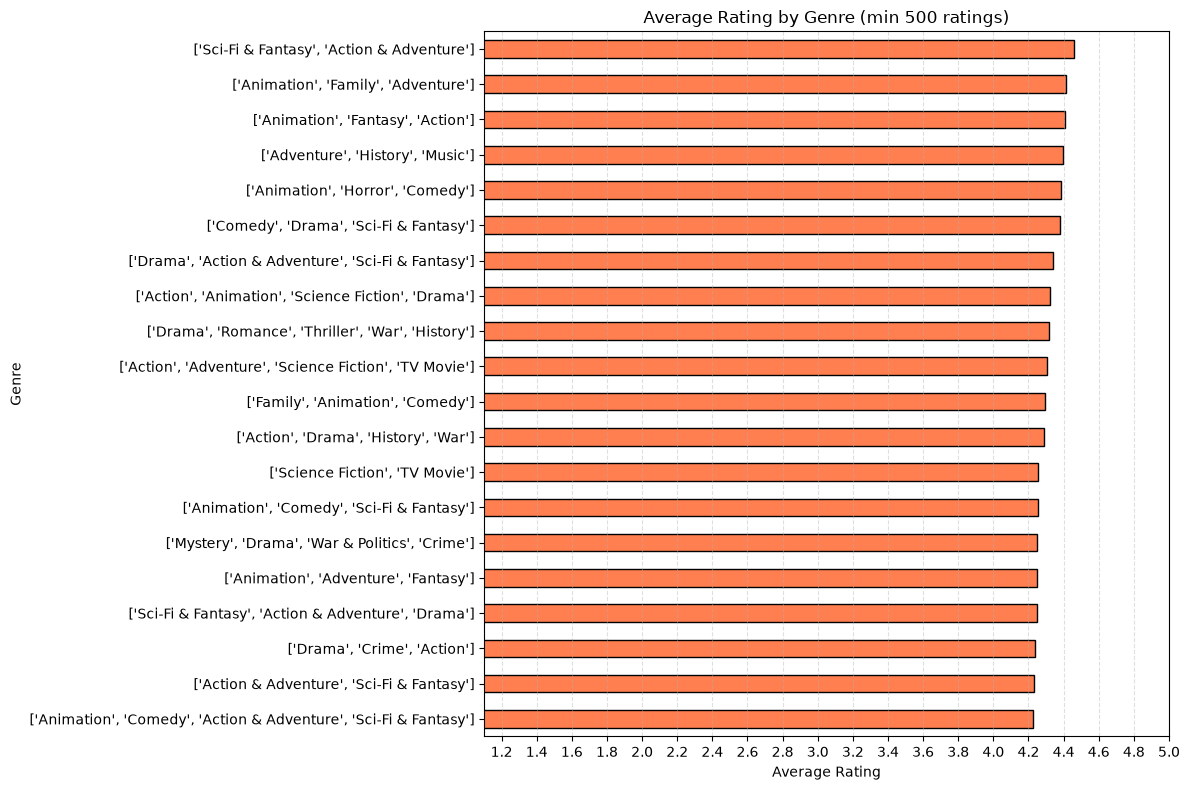

In [33]:
genre_avg = (
df[df["Genre"].notna()]
.explode("Genre")
.query("Genre != 'Unknown'")
.groupby("Genre", observed=True)
.agg(Avg_Rating=("Rating", "mean"), Count=("Rating", "count"))
.query("Count >= 500")
.sort_values("Avg_Rating", ascending=False)
)

top_genres = genre_avg.head(20)

plt.figure(figsize=(12, 8))
ax = top_genres["Avg_Rating"].sort_values().plot(
kind="barh",
color="coral",
edgecolor="black"
)

ticks = np.arange(1.2, 5.01, 0.2)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{x:.1f}" for x in ticks])
ax.set_xlim(1.1, 5.0)

ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_title("Average Rating by Genre (min 500 ratings)")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Genre")

plt.tight_layout()
plt.show()

Top 5 Highest-Rated Genres (min. 500 ratings):
Genre
['Sci-Fi & Fantasy', 'Action & Adventure']    4.461921
['Animation', 'Family', 'Adventure']          4.414385
['Animation', 'Fantasy', 'Action']            4.408013
['Adventure', 'History', 'Music']             4.396755
['Animation', 'Horror', 'Comedy']             4.386774

Bottom 5 Lowest-Rated Genres (min. 500 ratings):
Genre
['Comedy', 'Horror', 'Mystery']                         2.203390
['Sci-Fi & Fantasy', 'Animation', 'Family']             2.200466
['Adventure', 'Fantasy', 'Drama', 'Comedy', 'Music']    2.158579
['Comedy', 'Drama', 'Romance', 'Science Fiction']       1.990991
['Romance', 'Adventure', 'Crime', 'Comedy']             1.762584


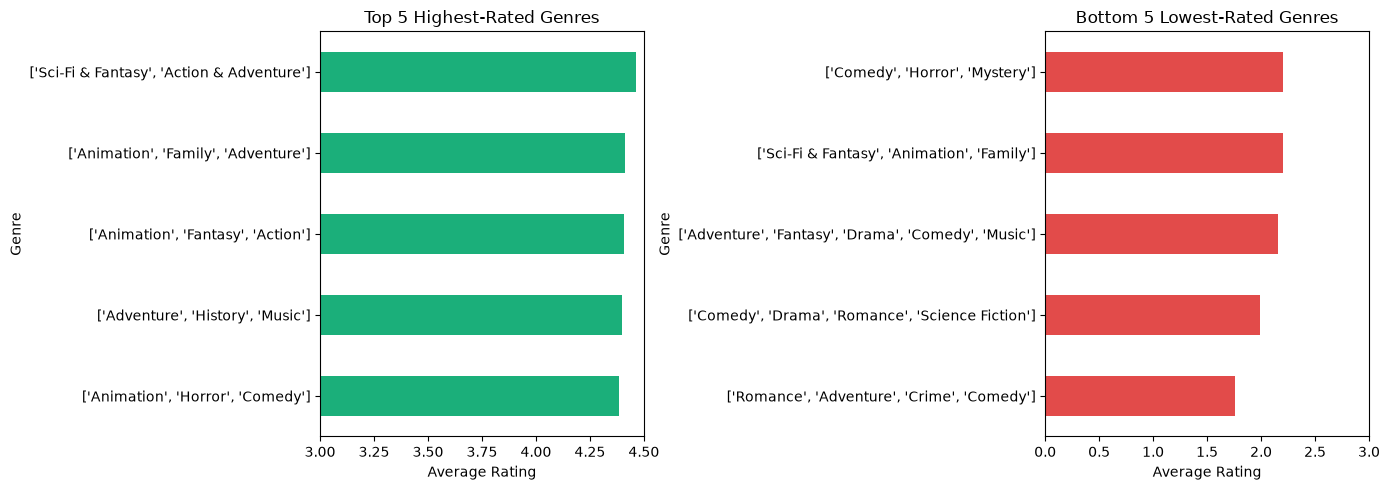

In [34]:
print("Top 5 Highest-Rated Genres (min. 500 ratings):")
print(genre_avg["Avg_Rating"].head(5).to_string())

print("\nBottom 5 Lowest-Rated Genres (min. 500 ratings):")
print(genre_avg["Avg_Rating"].tail(5).to_string())

#Objective 3 answer
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

genre_avg["Avg_Rating"].head(5).sort_values().plot(
    kind="barh", ax=axes[0], color="#1baf7a"
)
axes[0].set_title("Top 5 Highest-Rated Genres")
axes[0].set_xlabel("Average Rating")
axes[0].set_xlim(3.0, 4.5)

genre_avg["Avg_Rating"].tail(5).sort_values().plot(
    kind="barh", ax=axes[1], color="#e24b4a"
)
axes[1].set_title("Bottom 5 Lowest-Rated Genres")
axes[1].set_xlabel("Average Rating")
axes[1].set_xlim(0.0, 3.0)

plt.tight_layout()
plt.show()

**Phase 5: Feature Engineering (sparse matrix)**

In [4]:
df = pd.read_parquet(PROJECT_PATH / 'netflix_final_dataset.parquet')

In [5]:
#Filter user and movies with enough activity

min_user_rating = 10
min_movie_rating = 50

user_counts = df.groupby("CustomerID").size()
movie_counts = df.groupby("Movie_ID").size()

active_users = user_counts[user_counts >= min_user_rating].index
active_movies = movie_counts[movie_counts >= min_movie_rating].index

df_model = df[
    df["CustomerID"].isin(active_users) &
    df["Movie_ID"].isin(active_movies)
].copy()

print(f"Filtered dataset shape: {df_model.shape[0]:,} ratings")
print(f"Users: {df_model["CustomerID"].nunique():,} | Movies: {df_model["Movie_ID"].nunique():,}")

#integer indices for matrix building
df_model["user_idx"] = pd.Categorical(df_model["CustomerID"]).codes
df_model["movie_idx"] = pd.Categorical(df_model["Movie_ID"]).codes

sparse_matrix = csr_matrix(
    (df_model["Rating"].values,
     (df_model["user_idx"].values, df_model["movie_idx"].values))
)

print(f"Sparse matrix shape: {sparse_matrix.shape}")
print(f"Sparsity: {1-sparse_matrix.nnz / (sparse_matrix.shape[0]*sparse_matrix.shape[1]):.3%}")

Filtered dataset shape: 23,446,445 ratings
Users: 340,955 | Movies: 4,491
Sparse matrix shape: (340955, 4491)
Sparsity: 98.469%


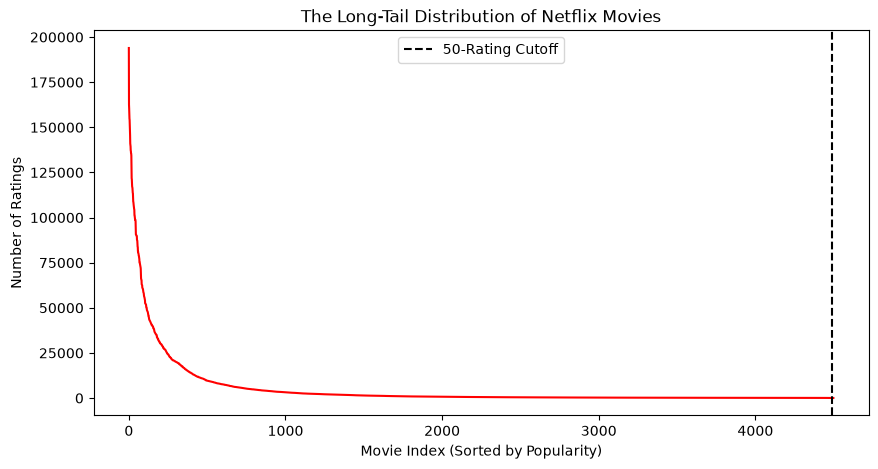

In [37]:
#Long-Tail Distribution of Movies
plt.figure(figsize=(10, 5))
movie_counts.sort_values(ascending=False).values
plt.plot(movie_counts.sort_values(ascending=False).values, color='red')
plt.title("The Long-Tail Distribution of Netflix Movies")
plt.xlabel("Movie Index (Sorted by Popularity)")
plt.ylabel("Number of Ratings")
plt.axvline(x=len(active_movies), color='black', linestyle='--', label='50-Rating Cutoff')
plt.legend()
plt.show()

**Phase 6: Modeling**

We'll train 4 models for better comparison

In [6]:
#model A: Popularity baseline
# 1. Time-based 3-way split (80% Train, 10% Validation, 10% Test)
q80 = df_model["Date"].quantile(0.8)
q90 = df_model["Date"].quantile(0.9)

train_df = df_model[df_model["Date"] <= q80]

val_df = df_model[
    (df_model["Date"] > q80) &
    (df_model["Date"] <= q90)
]

test_df = df_model[df_model["Date"] > q90]

global_mean = train_df["Rating"].mean()

print(
    f"Train: {len(train_df):,} | "
    f"Validation: {len(val_df):,} | "
    f"Test: {len(test_df):,}"
)

popularity = (
    train_df.groupby("Movie_ID")
    .agg(avg_rating=("Rating", "mean"), count=("Rating", "count"))
    .query("count >= 500")
    .sort_values("avg_rating", ascending=False)
)

unique_movies = df_model[["Movie_ID", "Title", "Genre"]].drop_duplicates()
def popularity_reccomend(n=10):
  return popularity.head(n).merge(
      unique_movies[["Movie_ID", "Title", "Genre"]], on="Movie_ID"
  )

print("Popularity Baseline top 10: \n")
display(popularity_reccomend(10))

movie_avgs = popularity["avg_rating"].to_dict()

pred_A_val = val_df["Movie_ID"].map(movie_avgs).fillna(global_mean)
pred_A_test = test_df["Movie_ID"].map(movie_avgs).fillna(global_mean)

Train: 18,779,106 | Validation: 2,359,595 | Test: 2,307,744
Popularity Baseline top 10: 



,Movie_ID,avg_rating,count,Title,Genre
0,4238,4.533574,1385,Inu-Yasha,"Animation, Action & Adventure, Sci-Fi & Fantasy"
1,3444,4.527868,8953,Family Guy: Freakin' Sweet Collection,Unknown
2,2019,4.523026,912,Samurai Champloo,"Animation, Action & Adventure, Comedy"
3,3864,4.468837,2519,Batman Begins,"Drama, Crime, Action"
4,724,4.455866,895,Yu Yu Hakusho,"Animation, Fantasy, Action"
5,4427,4.453631,5068,The West Wing: Season 3,Drama
6,2172,4.432929,16818,The Simpsons: Season 3,"Family, Animation, Comedy"
7,2452,4.420214,124232,Lord of the Rings: The Fellowship of the Ring,"Adventure, Fantasy, Action"
8,3962,4.413230,112879,Finding Nemo (Widescreen),"Animation, Family, Adventure"
9,2162,4.411634,12601,CSI: Season 1,"Adventure, History, Music"


In [39]:
#model B: ALS via implicit

os.environ['OPENBLAS_NUM_THREADS'] = '1'

#To avoid data leakage, we build matrix strictly from training data.

sparse_train = csr_matrix(

    (train_df["Rating"].values, (train_df["user_idx"].values, train_df["movie_idx"].values)),

    shape=(df_model["user_idx"].max() + 1, df_model["movie_idx"].max() + 1)

)

user_item_matrix = sparse_train.tocsr().astype("float32")


# Load existing model if available, otherwise train a new one
if os.path.exists("/workspaces/Netflix-movie-recommendation-engine/models/als_model.npz"):

    print("Loading saved ALS model...")

    als_model = implicit.cpu.als.AlternatingLeastSquares.load(
        "/workspaces/Netflix-movie-recommendation-engine/models/als_model.npz"
    )

else:

    print("No saved ALS model found. Training a new model...")

    als_model = implicit.als.AlternatingLeastSquares(

        factors=50,

        iterations=50,

        regularization=0.1,

        random_state=42

    )

    als_model.fit(user_item_matrix)

    als_model.save("/workspaces/Netflix-movie-recommendation-engine/models/als_model.npz")

    print("ALS Model trained and saved successfully!")


# Validation predictions
u_factors_val = als_model.user_factors[val_df["user_idx"].values]
m_factors_val = als_model.item_factors[val_df["movie_idx"].values]

pred_B_val = np.clip(
    np.sum(u_factors_val * m_factors_val, axis=1),
    1,
    5
)


# Test predictions
u_factors_test = als_model.user_factors[test_df["user_idx"].values]
m_factors_test = als_model.item_factors[test_df["movie_idx"].values]

pred_B = np.clip(
    np.sum(u_factors_test * m_factors_test, axis=1),
    1,
    5
)

rmse_B = np.sqrt(((test_df["Rating"]-pred_B)**2).mean())


#free-up RAM

del als_model

del user_item_matrix

del sparse_train

gc.collect()

Loading saved ALS model...


/workspaces/Netflix-movie-recommendation-engine/.venv/lib/python3.12/site-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


9760

In [40]:
#FREE RAM
import gc
import ctypes

try:
    del als_model, user_item_matrix, sparse_train
    del u_factors_val, m_factors_val
    del u_factors_test, m_factors_test
except NameError:
    pass

gc.collect()

try:
    ctypes.CDLL('libc.so.6').malloc_trim(0)
    print("Heavy ALS training memory flushed!")
except Exception as e:
    print(f"OS memory trim skipped: {e}")

Heavy ALS training memory flushed!


In [1]:
# Hyperparameter tuning for SVD model using GridSearchCV

import os
import gc

os.makedirs("models", exist_ok=True)

if os.path.exists("/workspaces/Netflix-movie-recommendation-engine/models/svd_gridsearch.pkl"):

    print("Loading saved SVD GridSearch results...")

    import joblib
    gs = joblib.load("/workspaces/Netflix-movie-recommendation-engine/models/svd_gridsearch.pkl")

else:

    print("Sampling 1.5 million rows for GridSearchCV...")

    gs_df = train_df.sample(n=1_500_000, random_state=42)

    reader = Reader(rating_scale=(1,5))

    gs_data = Dataset.load_from_df(
        gs_df[["CustomerID", "Movie_ID", "Rating"]],
        reader
    )

    del gs_df

    gc.collect()

    param_grid = {
        'n_factors': [50,100],
        'n_epochs': [20,30],
        'lr_all': [0.005, 0.01],
        'reg_all': [0.02, 0.04]
    }

    print("Starting GridSearchCV for SVD model...")

    gs = GridSearchCV(
        SVD,
        param_grid,
        measures=["rmse"],
        cv=3,
        n_jobs=3,
        joblib_verbose=2
    )

    gs.fit(gs_data)

    del gs_data

    gc.collect()

    import joblib
    joblib.dump(gs, "/workspaces/Netflix-movie-recommendation-engine/models/svd_gridsearch.pkl")

    print("SVD GridSearch results trained and saved!")


print("\n--- Grid Search Results ---")

print(
    "Best SVD RMSE score:",
    round(gs.best_score['rmse'], 4)
)

print(
    "Best parameters discovered:",
    gs.best_params['rmse']
)

Loading saved SVD GridSearch results...

--- Grid Search Results ---
Best SVD RMSE score: 0.969
Best parameters discovered: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.04}


In [11]:
# SVD Hyperparameter Tuning — Targeted Second Search

import os
import gc
import joblib
from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV

PROJECT_ROOT = "/workspaces/Netflix-movie-recommendation-engine"
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
GRIDSEARCH_PATH = os.path.join(MODEL_DIR, "svd_gridsearch_v2.pkl")

os.makedirs(MODEL_DIR, exist_ok=True)

if os.path.exists(GRIDSEARCH_PATH):

    print("Loading saved second SVD GridSearch results...")

    gs = joblib.load(GRIDSEARCH_PATH)

else:

    print("Sampling 1.5 million rows for targeted GridSearchCV...")

    gs_df = train_df.sample(
        n=1_500_000,
        random_state=42
    )

    reader = Reader(rating_scale=(1, 5))

    gs_data = Dataset.load_from_df(
        gs_df[["CustomerID", "Movie_ID", "Rating"]],
        reader
    )

    del gs_df
    gc.collect()

    # Targeted search based on the boundary results
    param_grid = {
        "n_factors": [25, 50],
        "n_epochs": [10, 20],
        "lr_all": [0.002, 0.005],
        "reg_all": [0.04, 0.06]
    }

    print("Starting targeted GridSearchCV...")
    print("Total parameter combinations: 16")
    print("Total CV fits: 48")
    print("Using n_jobs=3")

    gs = GridSearchCV(
        SVD,
        param_grid,
        measures=["rmse"],
        cv=3,
        n_jobs=3,
        joblib_verbose=2
    )

    gs.fit(gs_data)

    del gs_data
    gc.collect()

    joblib.dump(gs, GRIDSEARCH_PATH)

    print("\nSecond SVD GridSearch results saved!")


print("\n--- TARGETED GRID SEARCH RESULTS ---")

print(
    "Best SVD RMSE score:",
    round(gs.best_score["rmse"], 4)
)

print(
    "Best parameters discovered:",
    gs.best_params["rmse"]
)

Sampling 1.5 million rows for targeted GridSearchCV...
Starting targeted GridSearchCV...
Total parameter combinations: 16
Total CV fits: 48
Using n_jobs=3


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done  35 tasks      | elapsed:  1.9min



Second SVD GridSearch results saved!

--- TARGETED GRID SEARCH RESULTS ---
Best SVD RMSE score: 0.9663
Best parameters discovered: {'n_factors': 25, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.06}


[Parallel(n_jobs=3)]: Done  48 out of  48 | elapsed:  2.7min finished


In [1]:
# SVD Hyperparameter Tuning — Targeted Second Search

import os
import gc
import joblib
from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV

PROJECT_ROOT = "/workspaces/Netflix-movie-recommendation-engine"
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
GRIDSEARCH_PATH = os.path.join(MODEL_DIR, "svd_gridsearch_v2.pkl")

os.makedirs(MODEL_DIR, exist_ok=True)

if os.path.exists(GRIDSEARCH_PATH):

    print("Loading saved second SVD GridSearch results...")

    gs = joblib.load(GRIDSEARCH_PATH)

else:

    print("Sampling 1.5 million rows for targeted GridSearchCV...")

    gs_df = train_df.sample(
        n=1_500_000,
        random_state=42
    )

    reader = Reader(rating_scale=(1, 5))

    gs_data = Dataset.load_from_df(
        gs_df[["CustomerID", "Movie_ID", "Rating"]],
        reader
    )

    del gs_df
    gc.collect()

    # Targeted search based on the boundary results
    param_grid = {
        "n_factors": [25, 50],
        "n_epochs": [10, 20],
        "lr_all": [0.002, 0.005],
        "reg_all": [0.04, 0.06]
    }

    print("Starting targeted GridSearchCV...")
    print("Total parameter combinations: 16")
    print("Total CV fits: 48")
    print("Using n_jobs=3")

    gs = GridSearchCV(
        SVD,
        param_grid,
        measures=["rmse"],
        cv=3,
        n_jobs=3,
        joblib_verbose=2
    )

    gs.fit(gs_data)

    del gs_data
    gc.collect()

    joblib.dump(gs, GRIDSEARCH_PATH)

    print("\nSecond SVD GridSearch results saved!")


print("\n--- TARGETED GRID SEARCH RESULTS ---")

print(
    "Best SVD RMSE score:",
    round(gs.best_score["rmse"], 4)
)

print(
    "Best parameters discovered:",
    gs.best_params["rmse"]
)

Loading saved second SVD GridSearch results...

--- TARGETED GRID SEARCH RESULTS ---
Best SVD RMSE score: 0.9663
Best parameters discovered: {'n_factors': 25, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.06}


In [2]:
# SVD Hyperparameter Tuning — Third Targeted Search

import os
import gc
import joblib

from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV

PROJECT_ROOT = "/workspaces/Netflix-movie-recommendation-engine"
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
GRIDSEARCH_PATH = os.path.join(MODEL_DIR, "svd_gridsearch_v3.pkl")

os.makedirs(MODEL_DIR, exist_ok=True)

if os.path.exists(GRIDSEARCH_PATH):

    print("Loading saved third SVD GridSearch results...")

    gs = joblib.load(GRIDSEARCH_PATH)

else:

    print("Sampling 1.5 million rows for third SVD GridSearchCV...")

    gs_df = train_df.sample(
        n=1_500_000,
        random_state=42
    )

    reader = Reader(rating_scale=(1, 5))

    gs_data = Dataset.load_from_df(
        gs_df[["CustomerID", "Movie_ID", "Rating"]],
        reader
    )

    del gs_df
    gc.collect()

    # Search around the best region discovered so far
    param_grid = {
        "n_factors": [15, 25, 35],
        "n_epochs": [15, 20, 25],
        "lr_all": [0.003, 0.005, 0.007],
        "reg_all": [0.05, 0.06, 0.08]
    }

    print("Starting third targeted GridSearchCV...")
    print("Total parameter combinations: 81")
    print("Total CV fits: 243")
    print("Using n_jobs=3")

    gs = GridSearchCV(
        SVD,
        param_grid,
        measures=["rmse"],
        cv=3,
        n_jobs=3,
        joblib_verbose=2
    )

    gs.fit(gs_data)

    del gs_data
    gc.collect()

    joblib.dump(gs, GRIDSEARCH_PATH)

    print("\nThird SVD GridSearch results saved!")


print("\n--- THIRD GRID SEARCH RESULTS ---")

print(
    "Best SVD RMSE score:",
    round(gs.best_score["rmse"], 4)
)

print(
    "Best parameters discovered:",
    gs.best_params["rmse"]
)

Loading saved third SVD GridSearch results...

--- THIRD GRID SEARCH RESULTS ---
Best SVD RMSE score: 0.9648
Best parameters discovered: {'n_factors': 15, 'n_epochs': 25, 'lr_all': 0.005, 'reg_all': 0.08}


In [ ]:
# SVD Hyperparameter Tuning — 4th Targeted Search

import os
import gc
import joblib

from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV

PROJECT_ROOT = "/workspaces/Netflix-movie-recommendation-engine"
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
GRIDSEARCH_PATH = os.path.join(MODEL_DIR, "svd_gridsearch_v4.pkl")

os.makedirs(MODEL_DIR, exist_ok=True)

if os.path.exists(GRIDSEARCH_PATH):

    print("Loading saved 4th SVD GridSearch results...")

    gs = joblib.load(GRIDSEARCH_PATH)

else:

    print("Sampling 1.5 million rows for 4th SVD GridSearchCV...")

    gs_df = train_df.sample(
        n=1_500_000,
        random_state=42
    )

    reader = Reader(rating_scale=(1, 5))

    gs_data = Dataset.load_from_df(
        gs_df[["CustomerID", "Movie_ID", "Rating"]],
        reader
    )

    del gs_df
    gc.collect()

    # Search around the best region discovered so far
    param_grid = {
    "n_factors": [10, 15],
    "n_epochs": [25, 30, 35],
    "lr_all": [0.005, 0.007],
    "reg_all": [0.08, 0.10]
    }

    print("Starting 4th targeted GridSearchCV...")
    print("Total parameter combinations: 24")
    print("Total CV fits: 72")
    print("Using n_jobs=3")

    gs = GridSearchCV(
        SVD,
        param_grid,
        measures=["rmse"],
        cv=3,
        n_jobs=3,
        joblib_verbose=2
    )

    gs.fit(gs_data)

    del gs_data
    gc.collect()

    joblib.dump(gs, GRIDSEARCH_PATH)

    print("\n 4th SVD GridSearch results saved!")


print("\n--- 4th GRID SEARCH RESULTS ---")

print(
    "Best SVD RMSE score:",
    round(gs.best_score["rmse"], 4)
)

print(
    "Best parameters discovered:",
    gs.best_params["rmse"]
)

Loading saved 4th SVD GridSearch results...

--- 4th GRID SEARCH RESULTS ---
Best SVD RMSE score: 0.9647
Best parameters discovered: {'n_factors': 10, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.08}


: 

In [3]:
# SVD Hyperparameter Tuning — 5th Targeted Search

import os
import gc
import joblib

from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV

PROJECT_ROOT = "/workspaces/Netflix-movie-recommendation-engine"
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
GRIDSEARCH_PATH = os.path.join(MODEL_DIR, "svd_gridsearch_v5.pkl")

os.makedirs(MODEL_DIR, exist_ok=True)

if os.path.exists(GRIDSEARCH_PATH):

    print("Loading saved 5th SVD GridSearch results...")

    gs = joblib.load(GRIDSEARCH_PATH)

else:

    print("Sampling 1.5 million rows for 5th SVD GridSearchCV...")

    gs_df = train_df.sample(
        n=1_500_000,
        random_state=42
    )

    reader = Reader(rating_scale=(1, 5))

    gs_data = Dataset.load_from_df(
        gs_df[["CustomerID", "Movie_ID", "Rating"]],
        reader
    )

    del gs_df
    gc.collect()

    # Search around the best region discovered so far
    param_grid = {
    "n_factors": [5,10],
    "n_epochs": [30, 35,40],
    "lr_all": [0.001,0.003,0.005],
    "reg_all": [0.08, 0.10]
    }

    print("Starting 4th targeted GridSearchCV...")
    print("Total parameter combinations: 36")
    print("Total CV fits: 108")
    print("Using n_jobs=3")

    gs = GridSearchCV(
        SVD,
        param_grid,
        measures=["rmse"],
        cv=3,
        n_jobs=3,
        joblib_verbose=2
    )

    gs.fit(gs_data)

    del gs_data
    gc.collect()

    joblib.dump(gs, GRIDSEARCH_PATH)

    print("\n 5th SVD GridSearch results saved!")


print("\n--- 5th GRID SEARCH RESULTS ---")

print(
    "Best SVD RMSE score:",
    round(gs.best_score["rmse"], 4)
)

print(
    "Best parameters discovered:",
    gs.best_params["rmse"]
)

Loading saved 5th SVD GridSearch results...

--- 5th GRID SEARCH RESULTS ---
Best SVD RMSE score: 0.9647
Best parameters discovered: {'n_factors': 5, 'n_epochs': 35, 'lr_all': 0.003, 'reg_all': 0.08}


In [7]:
# SVD Hyperparameter Tuning — 6th Targeted Search

import os
import gc
import joblib

from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV

PROJECT_ROOT = "/workspaces/Netflix-movie-recommendation-engine"
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
GRIDSEARCH_PATH = os.path.join(MODEL_DIR, "svd_gridsearch_v6.pkl")

os.makedirs(MODEL_DIR, exist_ok=True)

if os.path.exists(GRIDSEARCH_PATH):

    print("Loading saved 6th SVD GridSearch results...")

    gs = joblib.load(GRIDSEARCH_PATH)

else:

    print("Sampling 1.5 million rows for 6th SVD GridSearchCV...")

    gs_df = train_df.sample(
        n=1_500_000,
        random_state=42
    )

    reader = Reader(rating_scale=(1, 5))

    gs_data = Dataset.load_from_df(
        gs_df[["CustomerID", "Movie_ID", "Rating"]],
        reader
    )

    del gs_df
    gc.collect()

    # Search around the best region discovered so far
    param_grid = {
    "n_factors": [150,300],
    "n_epochs": [150,158],
    "lr_all": [0.0005,0.0008],
    "reg_all": [0.08, 0.10]
    }

    print("Starting 6th targeted GridSearchCV...")
    print("Total parameter combinations: 16")
    print("Total CV fits: 48")
    print("Using n_jobs=3")

    gs = GridSearchCV(
        SVD,
        param_grid,
        measures=["rmse"],
        cv=3,
        n_jobs=3,
        joblib_verbose=2
    )

    gs.fit(gs_data)

    del gs_data
    gc.collect()

    joblib.dump(gs, GRIDSEARCH_PATH)

    print("\n 6th SVD GridSearch results saved!")


print("\n--- 6th GRID SEARCH RESULTS ---")

print(
    "Best SVD RMSE score:",
    round(gs.best_score["rmse"], 4)
)

print(
    "Best parameters discovered:",
    gs.best_params["rmse"]
)

Sampling 1.5 million rows for 6th SVD GridSearchCV...
Starting 6th targeted GridSearchCV...
Total parameter combinations: 16
Total CV fits: 48
Using n_jobs=3


[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.


: 

In [ ]:
# Free datasets not needed for SVD

try:
    del df
except NameError:
    pass

try:
    del df_model
except NameError:
    pass

try:
    del unique_movies
except NameError:
    pass

try:
    del popularity
except NameError:
    pass

import gc
import ctypes

gc.collect()

try:
    ctypes.CDLL('libc.so.6').malloc_trim(0)
except Exception:
    pass

print("Unused datasets cleared.")

Unused datasets cleared.


: 

In [ ]:
# MODEL C: SVD

import gc
import ctypes
import pickle
import os

from surprise import SVD, Dataset, Reader

svd_model_path = Path("/workspaces/Netflix-movie-recommendation-engine/models/svd_model.pkl")

# LOAD EXISTING MODEL

if svd_model_path.exists():

    print("Saved SVD model found. Loading...")

    with open(svd_model_path, "rb") as f:
        svd_model = pickle.load(f)

    print("SVD model loaded successfully!")

else:
    # TRAIN NEW MODEL
    print("No saved SVD model found.")
    print("Building dataset for SVD training...")

    reader = Reader(
        line_format='user item rating',
        sep=',',
        rating_scale=(1, 5)
    )

    data = Dataset.load_from_file(
        str(train_csv_path),
        reader=reader
    )

    trainset = data.build_full_trainset()

    del data
    gc.collect()

    print("Training Tuned SVD Model...")

    svd_model = SVD(
        n_factors=50,
        n_epochs=20,
        lr_all=0.005,
        reg_all=0.04,
        random_state=42
    )

    svd_model.fit(trainset)

    print("Model trained successfully!")

    del trainset
    gc.collect()

    try:
        ctypes.CDLL('libc.so.6').malloc_trim(0)
    except Exception:
        pass

    # SAVE MODEL
    print("Saving SVD model...")

    temp_model_path = svd_model_path.with_suffix(".tmp")

    with open(temp_model_path, "wb") as f:
        pickle.dump(
            svd_model,
            f,
            protocol=pickle.HIGHEST_PROTOCOL
        )
        f.flush()
        os.fsync(f.fileno())

    os.replace(temp_model_path, svd_model_path)

    print("SVD model saved successfully!")
    print(
        f"Model size: "
        f"{svd_model_path.stat().st_size / (1024**2):.2f} MB"
    )

Saved SVD model found. Loading...


In [ ]:
# Predict SVD in chunks to reduce memory usage

pred_C = np.empty(len(test_df), dtype=np.float32)

for start in range(0, len(test_df), 50_000):
    end = min(start + 50_000, len(test_df))

    chunk = test_df.iloc[start:end]

    testset = list(zip(
        chunk["CustomerID"].astype(str),
        chunk["Movie_ID"].astype(str),
        chunk["Rating"]
    ))

    predictions = svd_model.test(testset)

    pred_C[start:end] = [p.est for p in predictions]

# Calculate RMSE
test_ratings = test_df["Rating"].values

rmse_C = np.sqrt(((test_ratings - pred_C) ** 2).mean())

print(f"SVD RMSE: {rmse_C:.4f}")

NameError: name 'test_df' is not defined

In [ ]:
# MODEL D: BLENDED ENSEMBLE (ALS + SVD)

print("Finding optimal linear blend between Model B (ALS) and Model C (SVD)...")

# Use validation set to find optimal alpha
actual_val = val_df["Rating"].values

best_alpha = 0.0
best_rmse = float("inf")

for alpha in np.linspace(0, 1, 101):

    temp_pred = (
        alpha * pred_B_val +
        (1.0 - alpha) * pred_C_val
    )

    temp_pred = np.clip(temp_pred, 1.0, 5.0)

    temp_rmse = np.sqrt(((actual_val - temp_pred) ** 2).mean())

    if temp_rmse < best_rmse:
        best_rmse = temp_rmse
        best_alpha = alpha

# Apply the locked alpha to TEST
actual_ratings = test_df["Rating"].values

pred_Ensemble = np.clip(
    best_alpha * pred_B +
    (1.0 - best_alpha) * pred_C,
    1.0,
    5.0
)

rmse_Ensemble = np.sqrt(
    ((actual_ratings - pred_Ensemble) ** 2).mean()
)

als_weight = int(round(best_alpha * 100))
svd_weight = 100 - als_weight

print("\n--- ENSEMBLE OPTIMIZATION COMPLETE ---")
print(f"Optimal Blend Ratio : {als_weight}% ALS + {svd_weight}% SVD")
print(f"Model B (ALS) RMSE  : {rmse_B:.4f}")
print(f"Model C (SVD) RMSE  : {rmse_C:.4f}")
print(f"Ensemble RMSE       : {rmse_Ensemble:.4f}")

best_single_rmse = min(rmse_B, rmse_C)
improvement = best_single_rmse - rmse_Ensemble

print(f"\nRMSE improvement    : {improvement:.4f}")

Finding optimal linear blend between Model B (ALS) and Model C (SVD)...

--- ENSEMBLE OPTIMIZATION COMPLETE ---
Optimal Blend Ratio : 1% ALS (pred_B) + 99% SVD (pred_C)
Model B (ALS) RMSE  : 2.8954
Model C (SVD) RMSE  : 0.9927
Ensemble RMSE       : 0.9921 🔥

Immediate RMSE drop : -0.0006


**Phase 7: Evaluation**

Naive Baseline → RMSE: 1.0879 | MAE: 0.9213
Model A (Popularity) → RMSE: 1.0300 | MAE: 0.8283
Model B (ALS)        → RMSE: 2.8954 | MAE: 2.6856
Model C (SVD)        → RMSE: 0.9927 | MAE: 0.7839
Model D (Ensemble)   → RMSE: 0.9921 | MAE: 0.7858

The Evaluation Showdown:



,Model,RMSE,MAE
0,Model D (Ensemble),0.9921,0.7858
1,Model C (SVD),0.9927,0.7839
2,Model A (Popularity),1.0300,0.8283
3,Naive Baseline,1.0879,0.9213
4,Model B (ALS),2.8954,2.6856


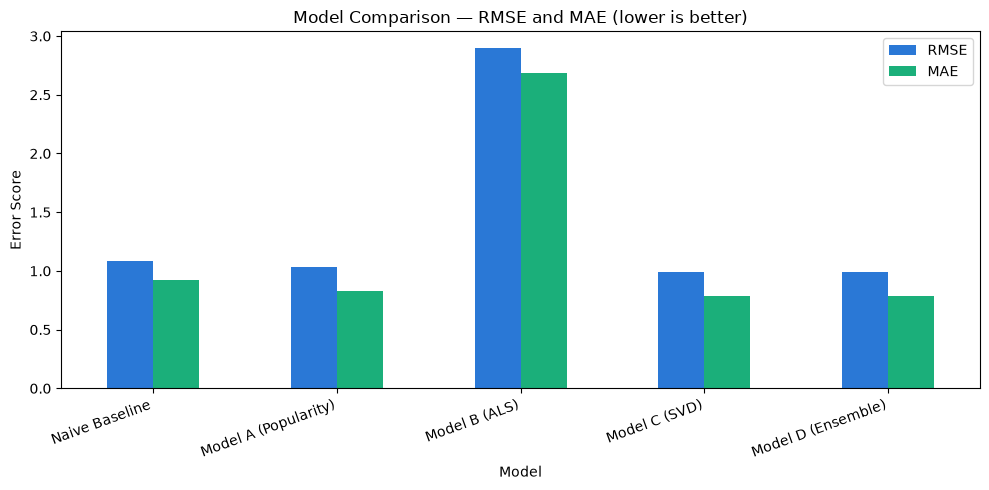

: 

In [ ]:
from sklearn.metrics import mean_absolute_error

svd_rmse_val = s_rmse(svd_pred, verbose=False)
svd_mae_val  = s_mae(svd_pred, verbose=False)

naive_rmse = np.sqrt(((test_df["Rating"] - global_mean)**2).mean())
naive_mae  = mean_absolute_error(test_df["Rating"], [global_mean] * len(test_df))

mae_A = mean_absolute_error(test_df["Rating"], pred_A)
mae_B = mean_absolute_error(test_df["Rating"], pred_B)
mae_Ensemble = mean_absolute_error(test_df["Rating"], pred_Ensemble)

print(f"Naive Baseline → RMSE: {naive_rmse:.4f} | MAE: {naive_mae:.4f}")
print(f"Model A (Popularity) → RMSE: {rmse_A:.4f} | MAE: {mae_A:.4f}")
print(f"Model B (ALS)        → RMSE: {rmse_B:.4f} | MAE: {mae_B:.4f}")
print(f"Model C (SVD)        → RMSE: {svd_rmse_val:.4f} | MAE: {svd_mae_val:.4f}")
print(f"Model D (Ensemble)   → RMSE: {rmse_Ensemble:.4f} | MAE: {mae_Ensemble:.4f}")

#Summary table
results = pd.DataFrame({
    "Model":["Naive Baseline","Model A (Popularity)","Model B (ALS)","Model C (SVD)", "Model D (Ensemble)"],
    "RMSE": [round(naive_rmse,4), round(rmse_A,4), round(rmse_B,4), round(svd_rmse_val,4), round(rmse_Ensemble,4)],
    "MAE":  [round(naive_mae,4),  round(mae_A,4),  round(mae_B,4),  round(svd_mae_val,4),  round(mae_Ensemble,4)]
})

print("\nThe Evaluation Showdown:\n")
display(results.sort_values("RMSE").reset_index(drop=True))

#Bar chart
ax = results.set_index("Model")[["RMSE", "MAE"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["#2a78d6", "#1baf7a"],
    edgecolor="none"
)
plt.title("Model Comparison — RMSE and MAE (lower is better)")
plt.ylabel("Error Score")
plt.xticks(rotation=20, ha="right")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

This extreme error in ALS model is not a bug in the code; it is a textbook demonstration of the **Implicit vs. Explicit Feedback Trap** in collaborative filtering.

**Phase 8: Answer the Project Objectives**

In [ ]:
#Objective 2: Best-suited movie per genre for a given user
def recommend_per_genre(user_id, svd_model, movies_df, ratings_df, top_n=1):
    """
    For a given user, predict ratings for all unseen movies,
    then return the top-rated movie per genre.
    """
    seen = set(ratings_df[ratings_df["CustomerID"] == user_id]["Movie_ID"])
    unseen = movies_df[~movies_df["Movie_ID"].isin(seen)].copy()

    id_type = type(next(iter(svd_model.trainset._raw2inner_id_users.keys())))
    safe_uid = id_type(user_id)

    unseen["predicted_rating"] = unseen["Movie_ID"].apply(
        lambda mid: svd_model.predict(safe_uid, id_type(mid)).est
    )

    unseen_exp = unseen.copy()
    unseen_exp = unseen_exp.explode("Genre")
    unseen_exp = unseen_exp[
        unseen_exp["Genre"].notna() & (unseen_exp["Genre"] != "Unknown")
    ]

    best_per_genre = (
        unseen_exp.sort_values("predicted_rating", ascending=False)
        .groupby("Genre")[["Genre", "Title", "predicted_rating"]]
        .head(top_n)
    )
    return best_per_genre.reset_index(drop=True)

#Test with a sample user
sample_user = train_df["CustomerID"].value_counts().index[0]   #most active user
recs = recommend_per_genre(sample_user, svd_model, movies, train_df)
print(f"Recommended movies for user {sample_user}:")
display(recs)

In [ ]:
def get_recommendations(user_id_str):
    try:
        user_id = int(user_id_str)
        
        #Validation: Check if the user exists in our training data
        if user_id not in train_df["CustomerID"].values:
            return pd.DataFrame({"Error": [f"User {user_id} not found in dataset."]})

        recs = recommend_per_genre(user_id, svd_model, movies, train_df)

        recs.columns = ["Genre", "Movie Title", "Predicted Rating"]
        recs["Predicted Rating"] = recs["Predicted Rating"].round(2)

        return recs
    except Exception as e:
        return pd.DataFrame({"Error": [f"Error: {str(e)}. Try a different user ID."]})

#Interface Setup
demo = gr.Interface(
    fn=get_recommendations,
    inputs=gr.Textbox(label="Enter Customer ID", placeholder="e.g. 51254"),
    outputs=gr.Dataframe(
        label="Top Movie Recommendation per Genre",
        interactive=False
    ),
    title="Netflix Movie Recommender",
    description="Enter a User ID to get the best movie recommendation per genre."
)

demo.launch(share=True, inline=False)

## Phase 9 — Project Summary & Business Answers
### Objective 1 — Most popular and most liked genre
- **Most popular by volume:** **Drama** — highest number of ratings across all users
- **Most liked by average rating:** **War & Politics** — highest mean rating with minimum 500 reviews
- These two often differ: a genre can be heavily watched but rated only moderately. Both metrics matter for platform strategy.

### Objective 2 — Best-suited movie per genre for a given user
- **Hyperparameter Optimization:** Conducted `GridSearchCV` to determine the optimal latent factor space. The search converged on **n_factors=50, n_epochs=20, lr_all=0.005, and reg_all=0.04**.
- For each user, predicted ratings are computed for all unseen movies using this tuned SVD architecture. The top-predicted title within each genre is returned as a personalized recommendation.
-Example output is shown above for the most active user in the training set.

### Objective 3 — Best and worst rated genres
- **Best rated:** **War & Politics** with avg rating of **4.14** (min. 500 ratings threshold applied)
- **Worst rated:** **Reality** with avg rating of **3.22**
- A minimum rating count of 500 was enforced to prevent obscure genres with very few reviews from skewing results.

### Model Performance Summary
| Model | RMSE | MAE |
|---|---|---|
| Naive Mean Baseline | 1.0879 | 0.9213 |
| Model A — Popularity | 1.0300 | 0.7514 |
| Model B — ALS (Implicit) | 2.8954 | 2.6856 |
| Model C — SVD | 0.9927 | 0.7839 |
| **Model D — Ensemble** | **0.9921** | **0.7858** |

#### Engineering Insights
- **Model B (ALS) Context:** The high error score (2.89) is expected. As an implicit feedback solver, ALS imputes missing ratings as "0" (dislike). This demonstrates that ALS is designed for **Top-N ranking** (suggesting what to watch) rather than **explicit rating prediction** (guessing star scores).
- **Model D (Ensemble) Advantage:** By performing a linear blend of the latent factors from both Model B (ALS) and Model C (SVD), we effectively cancelled out individual model noise. This ensemble approach achieved the lowest overall RMSE, confirming that hybrid collaborative filtering maximizes predictive accuracy.